# TP 8 - Bonus - Scrabble

## Codage des éléments du jeu

### Les lettres

!!! question Question 1
On fournit une liste de tuples `sac_depart` dont le premier élément est une lettre de l’alphabet (de type `str`), et dont le deuxième est un entier correspondant à sa valeur faciale.

À partir de cette liste, construire un dictionnaire nommé `valeur_faciale`, dont les clés sont les lettres et dont les valeurs sont les valeurs faciales associées.

Réaliser cette opération à l’aide d’une boucle traditionnelle dans un premier temps. Si vous vous en sentez capables, tentez de réaliser cette construction en compréhension.
!!!

In [ ]:
lettre_points = [('A', 1), ('B', 3), ('C', 3), ('D', 2), ('E', 1), ('F', 4),
                 ('G', 2), ('H', 4), ('I', 1), ('J', 8), ('K', 10), ('L', 1),
                 ('M', 2), ('N', 1), ('O', 1), ('P', 3), ('Q', 8), ('R', 1),
                 ('S', 1), ('T', 1), ('U', 1), ('V', 4), ('W', 10), ('X', 10),
                 ('Y', 10), ('Z', 10)]

In [ ]:
# construction de valeur_faciale

### Le sac de lettres et le chevalet

Le sac de lettres de départ est défini dans un dictionnaire où les lettres sont les clés, et les valeurs sont les occurrences des lettres correspondantes. Ce dictionnaire est fourni, et on peut y lire :

In [ ]:
# À executer
sac_depart = {'E': 15, 'A': 9, 'I': 8, 'N': 6, 'O': 6, 'R': 6, 'S': 6, 'T': 6,
              'G': 2, 'M': 3, 'B': 2, 'C': 2, 'P': 2, 'F': 2, 'H': 2, 'V': 2,
              'J': 1, 'Q': 1, 'K': 1, 'W': 1, 'X': 1, 'Y': 1, 'Z': 1}

signifiant qu’il y a 15 lettres `"E"`, 9 lettres `"A"`, 8 lettres `"I"`, *etc*.  



!!! question Question 2
Cependant, on a délibérément omis certaines lettres. Il manque le `"U"` présent 6 fois, le `"L"` présent 5 fois, et le `"D"` présent 3 fois.

Écrire les instructions permettant de compléter le contenu du sac. 

Attention, on ne doit pas modifier directement textuellement, mais grâce à des instructions python.	
!!!

In [ ]:
# instructions permettant de compléter le contenu de sac_depart


On souhaite maintenant modéliser le chevalet d’un joueur. On le modélisera par un dictionnaire dont chaque clé est un type de lettre, et la valeur associée est le nombre d’occurrences de cette lettre sur le chevalet du joueur. Un chevalet vide est un dictionnaire vide.

!!! example Exemple
Si le chevalet est composé des lettres `"X"`, `"E"`, `"D"`, `"E"`, alors le dictionnaire `chevalet` correspondant est `{"X": 1, "E": 2, "D": 1}`.
!!!

!!! question Question 3
Définir une fonction `ajoute_lettre` permettant d’ajouter la lettre fournie en argument, au chevalet dont le dictionnaire est également fourni en argument. 
!!!

In [ ]:
chevalet = {"X": 1, "E": 2, "D": 1}
ajoute_lettre(chevalet, "T")
print(chevalet) # {"X": 1, "E": 2, "D": 1, "T": 1}

ajoute_lettre(chevalet, "E")
print(chevalet) #{"X": 1, "E": 3, "D": 1, "T": 1}

On doit pouvoir également compter à tout instant le nombre de lettres présent sur le chevalet

!!! question Question 4
Définir une fonction `nb_lettres` renvoyant le nombres total de lettres sur le chevalet dont le dictionnaire le modélisant est fourni en argument. 
!!!

In [ ]:
chevalet = {"X": 1, "E": 3, "D": 1, "T": 1}
print(nb_lettres(chevalet)) #6

On fait remarquer que le sac de lettres est codé exactement de la même façon que le chevalet, ce qui fait que l’on peut connaitre, avec la fonction `nb_lettres`, le nombre de lettres dans le sac. 

On souhaite maintenant générer des tirages aléatoires de lettres dans le sac de lettres. Pour cela on utilise un générateur aléatoire de nombre entier. Nous utiliserons la fonction `randrange` de la bibliothèque `random`. Il sera donc nécessaire d’importer cette fonction par l’instruction
```python
from random import randrange	
```

On l’utilisera sous sa forme la plus basique `randrange(n)` qui tire un nombre entier dans l’intervalle [0, `n`[.


!!! question Question 5
Définir une fonction `tire_lettre(sac)` prenant un dictionnaire `sac` en argument et renvoyant une lettre du sac au hasard, après l’en avoir ôté. Il faudra bien sûr prendre en compte le fait qu’une lettre davantage représentée dans le sac a plus de chance d’être tirée qu’une autre moins représentée. On propose l’algorithme suivant :
- déterminer le nombre total `n` de lettres dans le sac ;
- tirer, avec `randrange`, un entier aléatoire `i` dans l’intervalle [0, `n`[;
- parcourir toutes les clés `lettre` de `sac` :
	- si `i` est supérieur ou égal à `sac[lettre]`, retirer à `i` cette valeur ;
	- sinon, décrémenter `sac[lettre]` d’une unité et renvoyer `lettre`
!!!

!!! question Question 6
Définir une fonction `reconstitue_chevalet(chevalet, sac)` prenant en argument les dictionnaires modélisant un chevalet et le sac de lettres. Cette fonction doit tirer autant de lettres du sac de lettres pour les placer sur le chevalet, de manière à atteindre 7 lettres dans la limite des lettres restant dans le sac. S’il n’y a pas suffisamment de lettres dans le sac, le chevalet ne sera donc pas rempli.
!!!

### Plateau de jeu

Afin de coder progressivement le jeu, on ne tient pas compte des modificateurs de points sur le plateau initialement.

Le plateau de jeu sur lequel on doit placer les lettres est modélisé par une liste de listes $15\times 15$, dont les cases sont initialement vides.


!!! question Question 7
Définir une fonction `initialise_plateau()` sans argument, et renvoyant la matrice (liste de listes) $15\times 15$ ne contenant que des caractères vides (`""`), codant une case vide. 

À l’aide de cette fonction, définir une variable `plateau` intialisée qui sera utilisée et remplie au fur et à mesure de la partie.
!!!

In [ ]:
plateau = initialise_plateau()

Pour vos premiers tests d’affichage de plateau, on fournit une fonction basique d’affichage. Quelque chose de plus professionnel sera proposé à la fin.

In [ ]:
def affichage_basique(plateau):
    print("  " + "".join([f"{i:2} " for i in range(len(plateau))]))  
    for i in range(len(plateau)):
        print(f"{i:2} " + "".join([f"{lettre:3}" for lettre in plateau[i]]))

In [ ]:
affichage_basique(plateau)

## Placement d’un mot

Tous les objets nécessaires à l’initialisation du jeu ont été codés. On peut maintenant placer des mots sur le plateau. Dans toutes la suite, on suppose que le mot placé l’est à une position autorisée, et l’on ne cherchera donc pas à tester les erreurs de placement.

Lorsqu’un mot est placé, les points associés aux lettres du mot comptent bien sûr dans le score, mais tout autre nouveau mot formé transversalement — de plus d’une lettre — à partir d’une lettre posée, doit également être pris en compte dans le score.

En voici une illustration :
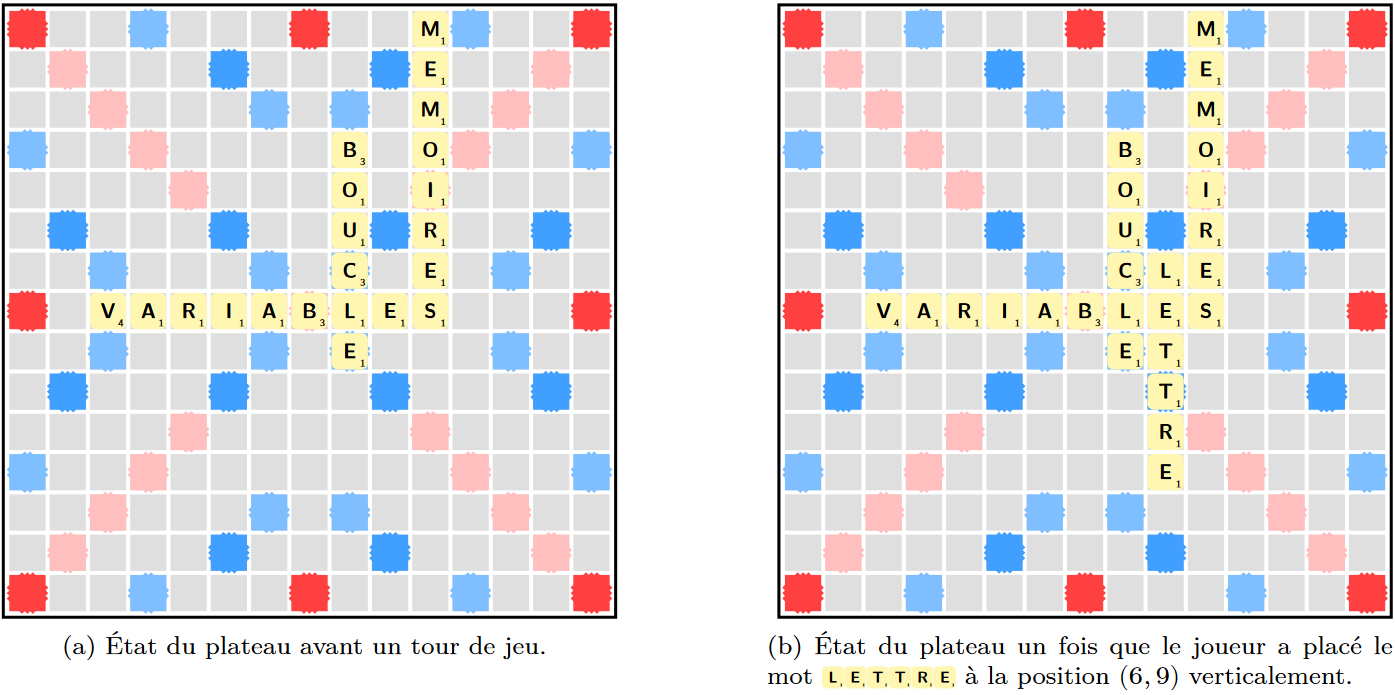

Le placement du mot `"LETTRE"`, génère $6\times 1=6$ points pour le mot lui-même, auquel on ajoute $3+1+1=5$ points pour le mot `"CLE"` formé horizontalement (grâce au `"L"` posé), et $1+1=2$ points pour le mot `"ET"` formé horizontalement également  (grâce au `"T"` posé). Soit un total de $6+5+2=13$ points.}


Nous allons déjà nous concentrer sur le calcul simple des points d’un mot.

!!! question Question 8
Définir une fonction `points` prenant en argument une chaine de caractères `mot`, et renvoyant les points rapportés par ce mot uniquement. Comme on ne s’intéresse pas aux modificateurs dans un premier temps, l’emplacement du mot n’influe pas sur les points rapportés.
!!!

In [ ]:
print(points("BOUCLE")) #10

Afin de pouvoir détecter d’éventuels autres nouveaux mots générés par le placement d’une lettre, on doit explorer les cases voisines d’une lettre posée. Afin de faciliter la programmation de certaines des prochaines fonctions, on propose de programmer une fonction utilitaire dans un premier temps.


!!! question Question 9
Définir une fonction `position_suivante(pos, direction, sens)` prenant en arguments :

- une position sur le plateau que l’on supposera fournie sous forme de doublet d’entiers `(i,j)`,
- une direction de recherche (`"H"` pour horizontal ou `"V"` pour vertical),
- un sens de parcours valant `1` ou `-1`.

Cette fonction devra renvoyer la nouvelle position sous forme de doublet d’entiers, telle que le déplacement d’une unité de pas ait été fait à partir de la position fournie, dans le sens et la direction fournis.

!!!

In [ ]:
print(position_suivante((1,1), "V", 1)) # (2,1)
print(position_suivante((1,1), "H", 1)) # (1,2)

On peut à présent s’intéresser aux nouveaux mots transversaux créés

!!! question Question 10
Définir une fonction `autre_mot(plateau, c, pos, direction)` prenant en arguments : 
- le plateau de jeu, c’est-à-dire une liste de listes,
- un caractère `c` 
- une position sur le plateau que l’on supposera fournie sous forme de doublet d’entiers,
- une direction de recherche (`"H"` pour horizontal ou `"V"` pour vertical)
	
La fonction vérifiera si des lettres sont adjacentes à la position fournie dans la direction indiquée. Si c’est le cas, elle renverra le mot entier selon cette direction passant par la position fournie. Sinon, une chaine vide est renvoyée.
	
L’origine des coordonnées de la grille du plateau est considérée en haut à gauche.
!!!	

!!! example Exemple 
Notons le plateau de jeu `p`.
Dans l’exemple fourni précédemment en illustration, pour rechercher les mots transversaux générés par la pose de la lettre `"L"`, il faudrait exécuter `autre_mot(p, "L", (6, 9), "H")`. Cette fonction devra renvoyer `"CLE"`.
L’exécution `autre_mot(p, "T", (8, 9), "H")` devra renvoyer `"ET"` ; celle de `autre_mot(p, "T", (9, 9), "H")` devra renvoyer `""`, …
!!!


Pour réaliser vos tests, on fournit le plateau dans l’état (a) de l’illustration proposée.

In [ ]:
plateau_test = [['', '', '', '', '', '', '', '', '', '', 'M', '', '', '', ''], ['', '', '', '', '', '', '', '', '', '', 'E', '', '', '', ''], ['', '', '', '', '', '', '', '', '', '', 'M', '', '', '', ''], ['', '', '', '', '', '', '', '', 'B', '', 'O', '', '', '', ''], ['', '', '', '', '', '', '', '', 'O', '', 'I', '', '', '', ''], ['', '', '', '', '', '', '', '', 'U', '', 'R', '', '', '', ''], ['', '', '', '', '', '', '', '', 'C', '', 'E', '', '', '', ''], ['', '', 'V', 'A', 'R', 'I', 'A', 'B', 'L', 'E', 'S', '', '', '', ''], ['', '', '', '', '', '', '', '', 'E', '', '', '', '', '', ''], ['', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], ['', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], ['', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], ['', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], ['', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], ['', '', '', '', '', '', '', '', '', '', '', '', '', '', '']]
plateau_test = [['.' if s=="" else s for s in ligne] for ligne in plateau_test]

In [ ]:
affichage_basique(plateau_test)

In [ ]:
# vos tests de «autre_mot» sur le plateau nommé «plateau_test»
print(autre_mot(plateau_test, "L", (6, 9), "H"), autre_mot(plateau_test, "T", (8, 9), "H"))

!!! question Question 11
Définir enfin une fonction `(plateau, mot, pos, direction)` prenant en arguments
- le plateau de jeu, c’est-à-dire une liste de listes,
- le mot à placer, donc une chaine de caractères,
- une position sur le plateau que l’on supposera fournie sous forme de doublet d’entiers,
- une direction de recherche (`"H"` pour horizontal ou `"V"` pour vertical)

Cette fonction réalisera les opérations suivantes :
- calculer le score du mot simple fourni, 
- rechercher tous les autres nouveaux mots transversaux générés, et ajouter les points qu’ils rapportent au score total
- déterminer la liste des lettres que le joueur aura réellement à poser : il faudra donc détecter si des lettres du mot à poser sont déjà présentes sur le chemin du mot!
- placer enfin les lettres du mot sur le plateau.

La fonction renverra alors le nombre total de points généré par le placement du mot, ainsi que la liste les lettres que le joueur doit poser pour cela, sous forme de liste de caractères.
!!!
!!! example Exemple
Dans l’exemple fourni en illustration, l’appel suivant doit donner
```python
>>> place_mot(plateau_test, "LETTRE", (6, 9), "V")
13, ["L", "T", "T", "R", "E"]
```
!!!

On pourra tester la modification du plateau avec la fonction d’affichage basique.

In [ ]:
# tests
place_mot(plateau_test, "LETTRE", (6, 9), "V")

Le tour de jeu d'un joueur, qui se retrouverait bloqué par une absence de mot valide, ou pour d'autres raisons, peut consister à échanger un nombre quelconque de lettre de son chevalet. En revanche, le joueur passe son tour une fois ses lettres échangées.

!!! question Question 12
Définir enfin une fonction `echange_lettres(lettres, chevalet, sac)` prenant en arguments echange_lettres(lettres, chevalet, sac):
- une chaine de caractère de toutes les lettres du chevalet à échanger, concaténées,
- le chevalet du joueur
- le sac de lettres,

Cette fonction doit retirer les lettres correspondantes du chevalet, le remettre dans le sac, et reconstituer le chevalet
!!!

On peut maintenant coder le tour complet d’un joueur.

!!! question Question 13
Définir enfin une fonction `joue(chevalet, sac, plateau, mot, pos, direction)` prenant en arguments
- le chevalet d’un joueur,
- le sac de lettres,
- le plateau de jeu, c’est-à-dire une liste de listes,
- le mot à placer, donc une chaine de caractères,
- une position sur le plateau que l’on supposera fournie sous forme de doublet d’entiers,
- une direction de recherche (`"H"` pour horizontal ou `"V"` pour vertical)

Cette fonction doit placer le mot grâce à la fonction précédente, extraire les lettres du chevalet du joueur, et tirer de nouvelles lettres pour reconstituer le chevalet. Cette fonction renvoie le score généré par le tour de jeu.
!!!

## Jouer!
### Initialisation d’une partie
On dispose maintenant d’un moteur de jeu totalement opérationnel, il ne reste qu’à jouer.

Les objets nécessaires au jeu sont : 
- le plateau et le sac de lettres
- les chevalets des joueurs
- les scores des joueurs

Ils doivent tous être initialisés en début de partie. Pour des raisons pratiques, les 

!!! question Question 14
Définir une fonction `debute_partie(nb_joueurs)`, prenant en argument un entier `nb_joueurs` supérieur ou égal à 1, correspondant au nombre de joueurs pour la nouvelle partie.

Cette fonction devra créer:
- un plateau vide,
- un sac de lettres initialisé,
- une liste de `nb_joueurs` chevalets, et les remplir
- une liste de `nb_joueurs` entiers nuls, correspondant aux scores des joueurs

l’ensemble de ces objets devront enfin être renvoyés par la fonction.

On pourra, bien sûr, utiliser toutes les fonctions qui ont pu être définies précédemment.
!!!

On peut alors utiliser cette fonction pour créer les objets en question, pour 2 joueurs par exemple.

Pour s'assurer que tout fonctionne, et pour pouvoir jouer, il faut afficher le chevalet du joueur, puis choisir le mot, l'emplacement, et la direction. Le score renvoyé par la fonction `joue` doit alors être ajouté au score du joueur. 

Attention, pour le moment, il n'y a aucune vérification de la validité du coup, donc il faut bien s'assurer que le coup est légal, en terme de placement.

In [ ]:
plateau, sac, chevalets, scores = debute_partie(2)

while True:
    joueur = not joueur  # 0 ou 1 en fonction du tour : alterner à la main. Par la suite, cela se fera automatiquement.

    print(f"Joueur {joueur} - score {scores[joueur]} - chevalet : ", end='')
    # affichage des lettres du chevalet 
    for lettre, nb_lettre in chevalets[joueur].items():
        print((lettre + ' ')*nb_lettre, end="")
    print()
    print()
    affichage_basique(plateau) # affichage du plateau avant que le nouveau joueur ne joue.
    # choisir ce qu'il faut placer
    continuer = input("voulez-vous continuez ? (O/N)")
    if continuer == "N":
        break
    
    mot = input("mot :")
    direction = input("direction (H ou V) : ")
    position_x = input("x : ")
    position_y = input("y : ")
    position = ( int(position_x),int(position_y) )
    scores[joueur] += joue(chevalets[joueur], sac, plateau, mot, position, direction)